# Anime Recommendation System: Collaborative Filtering (CF) + Content-Based Filtering (CBF) + evaluation </center>

# Introduction

The key issue this study undertakes to tackle is how one can efficiently personally recommend anime under such highly dynamic and huge content space. With platforms like MyAnimeList with over 12,000 listed anime series and a global audience with differing preferences, offering apt recommendations proportional to each user's interests is truly a challenge. This is especially difficult under sparse data conditions, where most users rate only a small percentage of existing anime. The result is that many anime titles are rated by limited users, creating a sparse user-item interaction matrix that makes typical recommendation techniques like Collaborative Filtering useless (Lü et al., 2012).

Therefore, the core problem concentrated on during this stage of the project is that there is no systematic evaluation and optimization of anime recommender models. To mitigate this, rigorous metric-based analysis must be performed that not only examines how well different models rank and recommend items but also exposes vulnerability areas such as bias, redundancy, or poor generalization. This will ensure that the recommender systems are technologically accurate but also useful and fair in practice.

# Dataset

The data used to conduct this analysis is called "Anime Recommendation Dataset" and was downloaded from Kaggle (https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database).

# Cleaning and Preprocessing

In [45]:
# Core libraries
import os
import time
import random
import heapq
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split

# Data handling
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import rankdata, spearmanr, kendalltau

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, normalize as sknormalize
from sklearn.impute import KNNImputer
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction & similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

# Model evaluation
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score, roc_auc_score

# Surprise library for collaborative filtering
from surprise import Reader, Dataset, SVD, SVDpp, NMF, accuracy
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

In [4]:
anime_df = pd.read_csv('anime.csv')
rating_df = pd.read_csv('rating.csv')

In [5]:
print(anime_df.shape)
print(anime_df.head())
print(rating_df.shape)
print(rating_df.head())

(12294, 7)
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
(7813737, 3)
   user_id  anime_id  rating
0        1        20      -1
1        1        24      -1
2        1        79      -1
3     

## Handling Missing values

In [6]:
# Check for missing values in each dataset 
print("\nMissing values in anime_df:")
print(anime_df.isnull().sum())  # This will give a count of missing values in each column of anime_df

print("\nMissing values in rating_df:")
print(rating_df.isnull().sum())  # This will give a count of missing values in each column of rating_df


Missing values in anime_df:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values in rating_df:
user_id     0
anime_id    0
rating      0
dtype: int64


In [7]:
# Fill missing 'genre' with 'Unknown'
anime_df['genre'] = anime_df['genre'].fillna('Unknown')

# Fill missing 'type' with mode
anime_df['type'] = anime_df['type'].fillna(anime_df['type'].mode()[0])

# Impute missing 'rating' (anime average rating) using KNN
knn_imputer = KNNImputer(n_neighbors=3)
anime_df[['rating']] = knn_imputer.fit_transform(anime_df[['rating']])

There are 62 rows out of 12294 are missing from the 'genre' column (only accounts for 0.50%). 
Thus, the missing cells in the 'genre' column were filled with "Unknown". This is so that all rows are kept and that the downstream model can still make predictions for all the data.

For imputation of the 'type' column, the mode (most frequent value) was used since it's a categorical feature.

Next for the imputation of the 'rating' column, the KNNImputer was used. Previously, optimization was done for the KNNImputer using GridSearchCV. However, the output was a warninng: <i>'UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan]'</i>. As such, no optimization was done for KNNImputers. This is because GridSearchCV optimizes models based on a target variable but for KNNImputer, there are nt target or y to predicts. S,o there is no meaningful score to calculate.

In [8]:
# Recheck for Missing Values
print("\nMissing values after final imputation:")
print(anime_df.isnull().sum())


Missing values after final imputation:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


## Filtering

In [9]:
# Filter out users with fewer than 5 interactions
user_interaction_counts = rating_df.groupby('user_id').size()
valid_users = user_interaction_counts[user_interaction_counts >= 5].index
rating_df_filtered = rating_df[rating_df['user_id'].isin(valid_users)]

Filtering out users with fewer than 5 interactions is to improve collaborative filtering (both memory-based and model-based). This will ensure that only users with enough data to compute meaningful similarities or train a model are included.

## Data Integration

Two different merging methods were tested to determine which structure was more appropriate for building recommender systems: using inner join and another using left join.

In [10]:
# Try both merge types
merged_inner = pd.merge(rating_df_filtered, anime_df, on='anime_id', how='inner')
merged_left = pd.merge(rating_df_filtered, anime_df, on='anime_id', how='left')

# See how many rows
print("Inner merge rows:", merged_inner.shape[0])
print("Left merge rows :", merged_left.shape[0])

# How many rows in left merge have missing anime data?
print("Rows with missing anime data (left merge):", merged_left['name'].isna().sum())

Inner merge rows: 7798934
Left merge rows : 7798944
Rows with missing anime data (left merge): 10


The left merge kept all rating records, even when an anime_id wasn’t found in anime_df. That’s why it has 10 more rows than the inner merge.

The inner merge automatically dropped those 10 unmatched ratings.

Thus, for a cleaner merge that avoids potential NaN issues, the inner merge method was chosen.

In [11]:
print("Merged file shape:", merged_inner.shape)
print(merged_inner.head())

Merged file shape: (7798934, 9)
   user_id  anime_id  rating_x    name  \
0        1        20        -1  Naruto   
1        3        20         8  Naruto   
2        5        20         6  Naruto   
3        6        20        -1  Naruto   
4       10        20        -1  Naruto   

                                               genre type episodes  rating_y  \
0  Action, Comedy, Martial Arts, Shounen, Super P...   TV      220      7.81   
1  Action, Comedy, Martial Arts, Shounen, Super P...   TV      220      7.81   
2  Action, Comedy, Martial Arts, Shounen, Super P...   TV      220      7.81   
3  Action, Comedy, Martial Arts, Shounen, Super P...   TV      220      7.81   
4  Action, Comedy, Martial Arts, Shounen, Super P...   TV      220      7.81   

   members  
0   683297  
1   683297  
2   683297  
3   683297  
4   683297  


## Handling Duplicates

In [12]:
# Check for any duplicated rows after the merging
merged_inner.duplicated(subset=['user_id', 'anime_id'], keep=False).sum()
dup_rows = merged_inner[merged_inner.duplicated(subset=['user_id', 'anime_id'], keep=False)]
print("Number of duplicate (user_id, anime_id) pairs:",len(dup_rows))
print(dup_rows)

Number of duplicate (user_id, anime_id) pairs: 14
         user_id  anime_id  rating_x                             name  \
134745     42653      2001         8       Tengen Toppa Gurren Lagann   
134746     42653      2001        10       Tengen Toppa Gurren Lagann   
644832     42653     11757         8                 Sword Art Online   
644833     42653     11757         5                 Sword Art Online   
801399     42653     16498         8               Shingeki no Kyojin   
801400     42653     16498         8               Shingeki no Kyojin   
962602     42653     22319         8                      Tokyo Ghoul   
962603     42653     22319         6                      Tokyo Ghoul   
1505379    42653     20507         7                         Noragami   
1505380    42653     20507         9                         Noragami   
3431366    42653      1575         8  Code Geass: Hangyaku no Lelouch   
3431367    42653      1575         6  Code Geass: Hangyaku no Lelouch   
4

In [13]:
# Deduplicate by averaging ratings for duplicates (user_id, anime_id)
dedup_df = merged_inner.groupby(['user_id', 'anime_id'], as_index=False).agg({'rating_x': 'mean'})

# Round up the ratings (for e.g., matrix factorization)
dedup_df['rating_x'] = dedup_df['rating_x'].round(1)

# Optionally merge back metadata if needed
dedup_df = dedup_df.merge(anime_df, on='anime_id', how='left')

In [14]:
# Check to see if deduplication was done correctly
# Any duplicates left?
print("Remaining duplicates:", dedup_df.duplicated(subset=['user_id', 'anime_id']).sum())

# Any missing ratings?
print("Missing ratings:", dedup_df['rating_x'].isna().sum())

# Any missing metadata after merge?
print("Missing anime metadata:", dedup_df['name'].isna().sum())

Remaining duplicates: 0
Missing ratings: 0
Missing anime metadata: 0


## Checking missing values of merged file

In [15]:
# Any missing values after the merging?
print("Missing Values per Column:")
print(dedup_df.isnull().sum())

Missing Values per Column:
user_id     0
anime_id    0
rating_x    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


## Handling Implicit Feedback (−1 Ratings)

In [16]:
print("Rating Range:")
print(dedup_df['rating_x'].describe())

Rating Range:
count    7.798927e+06
mean     6.141259e+00
std      3.727687e+00
min     -1.000000e+00
25%      6.000000e+00
50%      7.000000e+00
75%      9.000000e+00
max      1.000000e+01
Name: rating_x, dtype: float64


In [17]:
# Total number of rows
total_rows = len(dedup_df)

# Count rows with -1 ratings
num_negative_ones = (dedup_df['rating_x'] == -1).sum()

# Percentage of -1 ratings
percent_negative_ones = (num_negative_ones / total_rows) * 100

print(f"Total rows: {total_rows}")
print(f"Rows with -1 ratings: {num_negative_ones}")
print(f"Percentage of -1 ratings: {percent_negative_ones:.2f}%")

Total rows: 7798927
Rows with -1 ratings: 1474620
Percentage of -1 ratings: 18.91%


There are -1 ratings which are implicit feedback (according to the original kaggle link: https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database). This means that the users watched the anime but did not assign any rating. The -1 ratings would affect both the Model-based CF (Needs numeric ratings for matrix factorization) and Memory-based CF (Similarity calculations depend on actual scores) while Content-based can handle the -1 ratings. However, it would be more beneficial to drop these rows for consistency and comparability across all models. This way will also ensure that all downstream recommender systems are trained on explicit feedback which would lead to more accurate, interpretable, and meaningful recommendations.

In [18]:
# Remove rows with -1 ratings (implicit feedback)
dedup_df_cleaned = dedup_df[dedup_df['rating_x'] != -1].copy()

# Reset index after filtering
dedup_df_cleaned.reset_index(drop=True, inplace=True)

# Check the new shape and verify it's clean
print("Cleaned DataFrame shape:", dedup_df_cleaned.shape)
print("Any -1 ratings left?", (dedup_df_cleaned['rating_x'] == -1).any())

Cleaned DataFrame shape: (6324307, 9)
Any -1 ratings left? False


In [19]:
dedup_df_cleaned['episodes'] = pd.to_numeric(dedup_df_cleaned['episodes'], errors='coerce')

## Genre Text Cleaning for TF-IDF Compatibility

In [20]:
print("Anime Types:", dedup_df_cleaned['type'].unique())
print("Genres Sample:", dedup_df_cleaned['genre'].dropna().sample(5).values)

Anime Types: ['TV' 'Movie' 'OVA' 'Special' 'ONA' 'Music']
Genres Sample: ['Drama, Harem, Psychological, Romance, School'
 'Action, Comedy, Historical, Samurai, Sci-Fi, Super Power'
 'Drama, School, Super Power' 'Action, Adventure, Fantasy, Magic, Shounen'
 'Action, Adventure, Fantasy, Game, Romance']


From here, it can be seen that values in the 'genre' columns are stored as space-separated words instead of commas. This may not tokenize well for TF-IDF in content-based filtering. So, cleaning is required.

In [21]:
# Fill NaNs
dedup_df_cleaned['genre'] = dedup_df_cleaned['genre'].fillna('')

# Convert commas to spaces to create token list 
dedup_df_cleaned['genre'] = dedup_df_cleaned['genre'].str.replace(',', ' ')

# Replace spaces in multi-word genre names with underscores
dedup_df_cleaned['genre'] = dedup_df_cleaned['genre'].apply(lambda x: " ".join([g.strip().replace(' ', '_') for g in x.split()]))

# Remove double underscores (replace '__' with '_')
dedup_df_cleaned['genre'] = dedup_df_cleaned['genre'].str.replace(r'__+', '_', regex=True)

# Display a sample of cleaned genres to verify
print("Cleaned Genres Sample:", dedup_df_cleaned['genre'].dropna().sample(5).values)

Cleaned Genres Sample: ['Action Adventure Drama Fantasy Shounen'
 'Adventure Drama Fantasy Romance Sci-Fi' 'Historical Romance Shounen'
 'Comedy Drama Harem Romance Slice of Life'
 'Comedy Ecchi Romance Shounen Supernatural Vampire']


Outcome of the cleaning:
Example: "Slice of Life" becomes "Slice_of_Life" → treated as one genre in TF-IDF.
This way will make sure that terms like "Science Fiction" won't break into "Science" and "Fiction". It reflects real-world practice (treating compound genres as a unit) and also gives better control as well as improves semantic accuracy in TF-IDF.

# Sampling a subset

TF-IDF was initially tested on the entire dataset using tfidf_matrix.toarray() function which converted the dataset into a dense NumPy array. However, because the 'genre' column had 2,818 unique tokens across all anime rows, TF-IDF created one column per token. This resulted in a dataset of (6324307, 2818) which was too huge for the current device's memory to handle. A warning was received: 'MemoryError: Unable to allocate 133. GiB for an array with shape (6324307, 2818) and data type float64'. As such, a revised and resource-efficient strategy needed to be implemented. 

Instead of converting the TF-IDF output to a dense matrix, the original sparse matrix format was retained. This is more ideal for TF-IDF since most anime titles don’t share genres which makes the dataset naturally sparse. This way can avoid the memory issue and also allow the use of scalable downstream similarity calculations.

Furthermore, a subset of the dataset was used to simulate a real-world recommender system while keeping the computational workload manageable but also able to capture meaningful insights. This subset will be used for both collaborative filtering and content-based methods so that there will be a fair and balanced comparison between the approaches.

## Checking device's capabilities

In [46]:
import psutil

# Get virtual memory details
mem = psutil.virtual_memory()

# Print memory stats in GB
print(f"Total RAM: {mem.total / (1024 ** 3):.2f} GB")
print(f"Available RAM: {mem.available / (1024 ** 3):.2f} GB")
print(f"Used RAM: {mem.used / (1024 ** 3):.2f} GB")
print(f"Memory Usage: {mem.percent}%")


# Get disk usage of the root directory
disk = psutil.disk_usage('/')

print(f"Total Disk Space: {disk.total / (1024 ** 3):.2f} GB")
print(f"Used Disk Space: {disk.used / (1024 ** 3):.2f} GB")
print(f"Free Disk Space: {disk.free / (1024 ** 3):.2f} GB")
print(f"Disk Usage: {disk.percent}%")

Total RAM: 15.73 GB
Available RAM: 1.21 GB
Used RAM: 14.51 GB
Memory Usage: 92.3%
Total Disk Space: 475.66 GB
Used Disk Space: 322.71 GB
Free Disk Space: 152.95 GB
Disk Usage: 67.8%


After checking the current device's capacity, only 1.21 GB of RAM was available. Memory calculations showed that the dense TF-IDF matrix for 1% would require around 1.33 GB. Moreover, sparse matrix will be used instead of the dense TF-IDF matrix. So, taking 1% subset might be managable by the current device. In contrast, comparing a higher percentage such as 5% subset would need around 7.1 GB. This clearly is over the available memory even when using a sparse matrix.

## Random Sampling

In [37]:
# Parameters
SUBSET_FRAC = 0.01  
RANDOM_SEED = 42

# Sample 1% from the fully cleaned dataset
subset_df = dedup_df_cleaned.sample(frac=SUBSET_FRAC, random_state=RANDOM_SEED)
subset_df.reset_index(drop=True, inplace=True)

# Keep only users with at least 2 ratings
active_users = subset_df['user_id'].value_counts()
active_users = active_users[active_users >= 2].index
subset_df = subset_df[subset_df['user_id'].isin(active_users)].reset_index(drop=True)

# Confirm sizes
print(f"Random Subset shape: {subset_df.shape}")
print(f"Unique users: {subset_df['user_id'].nunique()}")
print(f"Unique anime: {subset_df['anime_id'].nunique()}")

# Save to CSV
subset_df.to_csv('subset_df_1percent.csv', index=False)

Random Subset shape: (48904, 9)
Unique users: 14414
Unique anime: 4830


## Stratified sampling

In [44]:
# Filter users with at least 2 ratings
active_users = dedup_df_cleaned['user_id'].value_counts()
active_users = active_users[active_users >= 2].index  # Keep only users with at least 2 ratings
filtered_df = dedup_df_cleaned[dedup_df_cleaned['user_id'].isin(active_users)]

# Perform Stratified Sampling
_, stratified_sample = train_test_split(
    filtered_df,  # Use filtered data with users having at least 2 ratings
    test_size=0.01,  # Keep 1% for the subset
    stratify=filtered_df['user_id'],  # Stratify by user_id to maintain the distribution
    random_state=42
)

stratified_sample.reset_index(drop=True, inplace=True)

# Confirm sizes
print(f"Stratified subset shape: {stratified_sample.shape}")
print(f"Unique users: {stratified_sample['user_id'].nunique()}")
print(f"Unique anime: {stratified_sample['anime_id'].nunique()}")

# Save to CSV
stratified_sample.to_csv("subset_df_stratified.csv", index=False)

Stratified subset shape: (63235, 9)
Unique users: 34994
Unique anime: 4944


From here, sampling at 1% data helps keep RAM usage low while also still being suitable for TF-IDF and Collaborative Filtering models. 
Two methods of sampling were tested. 

Random sampling involves selecting a subset of data randomly without taking into consideration the underlying distribution of the data. After applying random sampling, the output is a subset with 48,904 rows of 14,414 unique users and 4,830 unique animes. The distribution of users with fewer than two ratings could be uneven, and users with more ratings might not be adequately represented, potentially biasing the results.

For stratified sampling, it involves dividing the dataset into subgroups (or strata) based on the number of ratings per user and then sampling from each subgroup in proportion to its size. The resulting output gave a subset with 63,235 rows of 34,994 unique users and 4,944 unique animes. This sample maintains a better balance between users with multiple ratings. Because of this, it is a better representative of the active user base and improves the fairness of the comparison between recommendation approaches. 

As such, 1% stratified sampling was chosen.

## Dataset Preparation

In [47]:
df = pd.read_csv("subset_df_stratified.csv")
print("Dataset shape:", df.shape)
print("Columns:", df.columns)
print(df.head())
assert 'user_id' in df.columns and 'anime_id' in df.columns and 'rating_x' in df.columns, \
    "Dataset must contain 'user_id', 'anime_id', and 'rating_x' columns"

Dataset shape: (63235, 9)
Columns: Index(['user_id', 'anime_id', 'rating_x', 'name', 'genre', 'type', 'episodes',
       'rating', 'members'],
      dtype='object')
   user_id  anime_id  rating_x                           name  \
0    69093     22319       8.0                    Tokyo Ghoul   
1    59977      2612       7.0                  Spoon Oba-san   
2    49479      4224       7.0                      Toradora!   
3    59621      9834       9.0                        Level E   
4    69418       199       9.0  Sen to Chihiro no Kamikakushi   

                                               genre   type  episodes  rating  \
0  Action Drama Horror Mystery Psychological Sein...     TV      12.0    8.07   
1                                         Kids Magic     TV     130.0    6.83   
2                Comedy Romance School Slice of Life     TV      25.0    8.45   
3                              Comedy Sci-Fi Shounen     TV      13.0    7.58   
4                       Adventure Drama

In [48]:
print(df['rating_x'].describe())

count    63235.000000
mean         7.785166
std          1.563505
min          1.000000
25%          7.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: rating_x, dtype: float64


C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


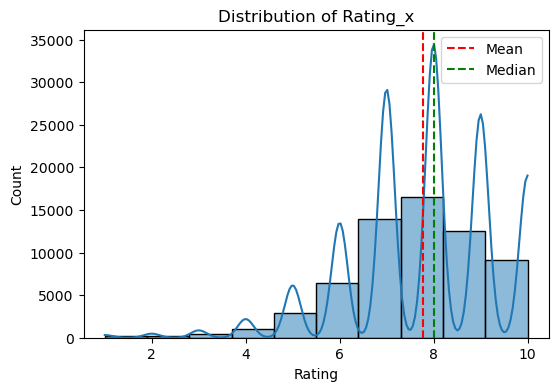

In [384]:
# Distribution of ratings
plt.figure(figsize=(6,4))
sns.histplot(df['rating_x'], bins=10, kde=True)
plt.axvline(df['rating_x'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['rating_x'].median(), color='green', linestyle='--', label='Median')
plt.title("Distribution of Rating_x")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend()
plt.show()

From the dataset distribution analysis of the user rating, it can be seen that users generally give high ratings.

In [209]:
# Check the Matrix Sparsity
num_users = df['user_id'].nunique()
num_items = df['anime_id'].nunique()
num_ratings = len(df)
sparsity = 1 - num_ratings / (num_users * num_items)
print(f"Matrix Sparsity: {sparsity:.2%}")

Matrix Sparsity: 99.96%


Prior to building and tuning the SVD and CBF models, the dataset structure was scrutinized. Sparsity is the proportion of missing or zero entries in a dataset. In terms of collaborative filtering, it refers to how many users have not rated most of the items. By examining matrix sparsity, it will show how much data is available for making predictions and how much data is missing.

From the sparsity analysis, it was found that 99.96% of the dataset is highly sparse. Most users have only rated a small fraction of the items. This dataset is extremely cold.

It is to be noted that the dataset used here was obtained through 1% stratified sampling from the full dataset (as shown in Assignment 1). This ensures that the current sample dataset maintains a similar distribution of ratings across users. Thus, this sparsity value is representative of the full dataset. It provides a realistic view of the challenges faced in building a recommendation system.

Also, due to this extreme sparsity, the metrics of Recall@k, F1@k and AUC-ROC are not suitable to be used as they become less reliable and potentially misleading. These metrices are heavily influenced by the number of relevant items per user which is often very small in sparse data. This can result in skewedness that do not reflect the actual performance of the model.

For more interpretable evaluation due to the cold dataset, metrics such as Precision@k, Hit Rate@k and Mean Reciprocal Rank (MRR) are better. These focus on ranking quality and relevance within the top-k recommendations which makes them more suitable for sparse recommendation. Coverage and novelty can also be used to assess the model's ability to recommend a diverse range of items besides just the most popular content.

In [207]:
reader = Reader(rating_scale=(1, 10))  
data = Dataset.load_from_df(df[['user_id', 'anime_id', 'rating_x']], reader)

In [208]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print(type(trainset))
print(type(testset))
print(testset[:3])

<class 'surprise.trainset.Trainset'>
<class 'list'>
[(55505, 6, 10.0), (7475, 3503, 7.0), (44129, 13469, 8.0)]


The output confirms that the trainset is from Surprise Trainset object which is required for training. It also confirms that the testset is a list of (user, item, rating) tuples which is needed for Surprise to do testing. 

In [212]:
# Build full anti-testset
anti_testset_full = trainset.build_anti_testset()

# Sample a manageable portion (10,000 entries)
anti_testset = sample(anti_testset_full, 10_000)

# Run predictions only on the smaller set
anti_predictions = best_model_svd.test(anti_testset)

An anti-testset was used instead of the regular test set for item-level analysis and metrics to evaluate the SVD model's robustness to out-of-distribution data. This is to gauge how well the SVD model performs on unseen diverse items instead of just overfitting to the specific distribution of the test set.

Here, only 10000 entries were used for the anti-testset as the current system faced memory warning when trying to build the full anti-testset.

The train/test split was utilized in training and testing SVD and CBF models. The anti-testset, on the other hand, served as the basis for recommendation properties emerging when models recommend items that are previously unseen. This pairing ensures predictive accuracy as well as realistic quality of recommendations is properly tested.


# Collaborative Recommender System (CF) - Singular Value Decomposition (SVD)

## Hyperparameter tuning with 3-fold CV

In [210]:
param_grid_svd = {
    'n_factors': [10, 20, 50],
    'n_epochs': [5, 10, 20],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.1, 0.4]
}
grid_search_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse', 'mae'], cv=3)
grid_search_svd.fit(data)
print("Best Parameters for SVD:", grid_search_svd.best_params)

Best Parameters for SVD: {'rmse': {'n_factors': 10, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.1}, 'mae': {'n_factors': 10, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.1}}


From the hyperparameter tuning, it was found that the best SVD model is that with low number of latent factors (10) but with high number of epochs (20). This might mean that a simple model trained longer performs better for this particularly sparse dataset. This might likely help the SVD model avoid overfitting while still be able to capture key latent patterns.

In [211]:
best_model_svd = grid_search_svd.best_estimator['rmse']
best_model_svd.fit(trainset)

In [213]:
# Sanity check: RMSE of the model
print("RMSE on Anti-Testset:", accuracy.rmse(anti_predictions))
full_testset = trainset.build_testset()
predictions_svd = best_model_svd.test(full_testset)
print("RMSE on Testset:", accuracy.rmse(predictions_svd))

RMSE: 0.5623
RMSE on Anti-Testset: 0.5623093973322935
RMSE: 1.0456
RMSE on Testset: 1.0455931704343067


From the output, it was found that RMSE on the anti-testset was 0.56 which was significantly lower than that of the regular testset which obtained 1.05. This could be because the anti-testset only contains unseen interactions which the model often predicts with more confidence due to the global trends such as item popularity. Despite this, RMSE alone is not ideal in ranking-focused applications.

## Evaluation Helpers

From the dataset distribution analysis, it was found that for rating_x, the mean rating is 7.78, median rating is 8 and the 75th percentile is 9. As such, a threshold rating of at least 7 was chosen when defining the "relevant" items in evaluation metrics such as precision, recall, MAP and NDCG. Lower thresholds might include items that the users were more neutral on and this would potentially dilute the meaning of relevance.

In [214]:
user_true = defaultdict(list)
user_pred_raw = defaultdict(list)

In [215]:
for pred in predictions_svd:
    user_pred_raw[pred.uid].append(pred)
    if pred.r_ui >= 7:
        user_true[pred.uid].append(pred.iid)

In [216]:
def get_user_true_and_pred(predictions, threshold=7, min_relevant=2):
    user_true = defaultdict(set)
    user_pred_raw = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        if true_r >= threshold:
            user_true[uid].add(iid)
        user_pred_raw[uid].append((iid, est, true_r))

    relevant_item_counts = defaultdict(int)
    for user_id, items in user_true.items():
        relevant_item_counts[len(items)] += 1

    print(f"\nDistribution of Relevant Items Per User (min_relevant={min_relevant}):")
    for num_relevant_items, count in sorted(relevant_item_counts.items()):
        print(f"{num_relevant_items} relevant items: {count} users")

    qualified_users = {uid for uid, items in user_true.items() if len(items) >= min_relevant}
    print(f"Users with at least {min_relevant} relevant items: {len(qualified_users)}")

    user_true = {uid: items for uid, items in user_true.items() if uid in qualified_users}
    user_pred = {
        uid: sorted(preds, key=lambda x: x[1], reverse=True)
        for uid, preds in user_pred_raw.items() if uid in qualified_users
    }

    return user_true, user_pred

## Evaluation Metrics

In [217]:
def build_unseen_dict(anti_testset):
    unseen_dict = defaultdict(set)
    for uid, iid, _ in anti_testset:
        unseen_dict[uid].add(iid)
    return unseen_dict

In [218]:
def precision_at_k(user_true, user_pred, k):
    precisions = []
    for uid in user_true:
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]
        true_iids = user_true[uid]
        precisions.append(len(set(pred_iids) & true_iids) / k)
    return np.mean(precisions)

In [219]:
def recall_at_k(user_true, user_pred, k):
    recalls = []
    for uid in user_true:
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]
        true_iids = user_true[uid]
        recalls.append(len(set(pred_iids) & true_iids) / len(true_iids))
    return np.mean(recalls)

In [220]:
def f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

In [221]:
def map_at_k(user_true, user_pred, k):
    average_precisions = []
    for uid in user_true:
        true_iids = user_true[uid]
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]

        hits = 0
        sum_precisions = 0
        for i, iid in enumerate(pred_iids):
            if iid in true_iids:
                hits += 1
                sum_precisions += hits / (i + 1)

        average_precisions.append(sum_precisions / len(true_iids))
    return np.mean(average_precisions)

In [222]:
def ndcg_at_k(user_true, user_pred, k):
    ndcgs = []
    for uid in user_true:
        true_iids = user_true[uid]
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]

        dcg = sum(1 / np.log2(i + 2) for i, iid in enumerate(pred_iids) if iid in true_iids)
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(true_iids), k)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)

In [223]:
def hit_rate_at_k(user_true, user_pred, k):
    hits = []
    for uid in user_true:
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]
        true_iids = user_true[uid]
        hits.append(int(bool(set(pred_iids) & true_iids)))  # 1 if relevant item is in the top-k
    return np.mean(hits)

In [224]:
def mrr_at_k(user_true, user_pred, k):
    rr = []
    for uid in user_true:
        pred_iids = [iid for iid, _, _ in user_pred[uid][:k]]
        true_iids = user_true[uid]
        relevant_positions = [i + 1 for i, iid in enumerate(pred_iids) if iid in true_iids]
        if relevant_positions:
            rr.append(1 / min(relevant_positions))
        else:
            rr.append(0)
    return np.mean(rr)

In [225]:
def coverage(user_pred, all_items):
    recommended_items = set()
    for uid, preds in user_pred.items():
        recommended_items.update([iid for iid, _, _ in preds])
    return len(recommended_items) / len(all_items)

In [226]:
def diversity(user_pred):
    diversities = []
    for uid, preds in user_pred.items():
        pred_iids = [iid for iid, _, _ in preds]
        diversities.append(len(set(pred_iids)) / len(pred_iids) if pred_iids else 0)
    return np.mean(diversities)

In [227]:
def novelty(user_true, user_pred, unseen_dict, top_k):
    novelty_scores = []
    for uid in user_true:
        pred_iids = [iid for iid, _, _ in user_pred[uid][:top_k]]
        unseen_items = [iid for iid in pred_iids if iid in unseen_dict[uid]]
        novelty_scores.append(len(unseen_items) / top_k)
    return np.mean(novelty_scores)

In [228]:
def get_topk_predictions(anti_predictions, k=10):
    user_topk_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in anti_predictions:
        user_topk_preds[uid].append((iid, est))

    # Sort and keep top-k for each user
    for uid in user_topk_preds:
        user_topk_preds[uid] = sorted(user_topk_preds[uid], key=lambda x: x[1], reverse=True)[:k]
    return user_topk_preds

## Compute SVD

In [229]:
all_item_ids = df['anime_id'].unique()

In [230]:
# Create a mapping from item_id to index
item_id_to_index = {item_id: index for index, item_id in enumerate(all_item_ids)}

In [231]:
for min_relevant in [2, 3]:
    user_true, user_pred = get_user_true_and_pred(predictions_svd, min_relevant=min_relevant)

    for k in [5, 10]:
        prec = precision_at_k(user_true, user_pred, k)
        rec = recall_at_k(user_true, user_pred, k)
        f1 = f1_at_k(prec, rec)
        mapk = map_at_k(user_true, user_pred, k)
        ndcg = ndcg_at_k(user_true, user_pred, k)
        hr = hit_rate_at_k(user_true, user_pred, k)
        mrr = mrr_at_k(user_true, user_pred, k)
        cov = coverage(user_pred, all_item_ids)
        unseen_dict = build_unseen_dict(anti_testset)
        novelty_score = novelty(user_true, user_pred, unseen_dict, k)
        div = diversity(user_pred)

        # Print all metrics including novelty
        print(f"\nSVD Metrics @ {k} (min_relevant={min_relevant})")
        print(f"Precision@{k}: {prec:.4f}")
        print(f"Recall@{k}: {rec:.4f}")
        print(f"F1@{k}: {f1:.4f}")
        print(f"MAP@{k}: {mapk:.4f}")
        print(f"NDCG@{k}: {ndcg:.4f}")
        print(f"Hit Rate@{k}: {hr:.4f}")
        print(f"MRR@{k}: {mrr:.4f}")
        print(f"Coverage: {cov:.4f}")
        print(f"Diversity: {div:.4f}")
        print(f"Novelty@{k}: {novelty_score:.4f}")


Distribution of Relevant Items Per User (min_relevant=2):
1 relevant items: 18962 users
2 relevant items: 5099 users
3 relevant items: 1762 users
4 relevant items: 769 users
5 relevant items: 306 users
6 relevant items: 159 users
7 relevant items: 81 users
8 relevant items: 38 users
9 relevant items: 23 users
10 relevant items: 14 users
11 relevant items: 7 users
12 relevant items: 4 users
13 relevant items: 9 users
14 relevant items: 3 users
17 relevant items: 2 users
21 relevant items: 1 users
Users with at least 2 relevant items: 8277

SVD Metrics @ 5 (min_relevant=2)
Precision@5: 0.5226
Recall@5: 0.9843
F1@5: 0.6827
MAP@5: 0.9712
NDCG@5: 0.9895
Hit Rate@5: 1.0000
MRR@5: 0.9929
Coverage: 0.8337
Diversity: 1.0000
Novelty@5: 0.0000

SVD Metrics @ 10 (min_relevant=2)
Precision@10: 0.2717
Recall@10: 0.9989
F1@10: 0.4272
MAP@10: 0.9842
NDCG@10: 0.9916
Hit Rate@10: 1.0000
MRR@10: 0.9929
Coverage: 0.8337
Diversity: 1.0000
Novelty@10: 0.0000

Distribution of Relevant Items Per User (min_re

The SVD-based recommendation model is evaluated with valuable observations of its performance under different user relevance thresholds. The data first displays a highly sparse user-item matrix. 18,962 out of the total users have just one relevant item and hence are removed from testing. Compared to the entire dataset that has 63235 users, only 8277 (13%) users have at least 2 relevant items and just 3178 (5%) users have 3 or more. This shows that the data is not only very sparse but also extremely shallow per user which makes collaborative learning challenging and reinforces the need for top-k recommendation metrices.

However, although the dataset is extremely sparse, the SVD model shows strong top-k ranking performance. From the metric score output, the SVD model achieves perfect hit rate of 1.0 across all settings. This means that at leaset one relevant item is always in the top-k recommendations. Despite this, the novelty is 0 meaning that the SVD model heavily recommends items that the users are already familiar with or are possibly very popular items. This means that the SVD model is accurate which is great for relevance but is bad at introducing new items. This is known as the serendipity problem.


With a minimum of two appropriate items, the model performs very well. At @5, the model performs high recall of 0.9843 and precision of 0.5226, resulting in a highly balanced F1 score of 0.6827. MAP (0.9712) and NDCG (0.9895) also guarantee not just relevant items are returned but also appropriately ranked. The best hit rate (1.0000) indicates all users were provided a relevant recommendation. Coverage is 0.8337, denoting good item distribution, and diversity is maximized to 1.0000. Novelty is 0.0000, suggesting recommendations are biased toward popular or known items.

By applying the stricter threshold of three relevant items, performance improves. Precision@5 rises to 0.7195, and recall remains high at 0.9595, making F1@5 score 0.8223. Coverage does drop slightly to 0.7233, but otherwise all scores remain high, and diversity is again flawless. Novelty remains a weak area, with a score of 0.0000. At @10, precision drops to 0.3867 with the longer list, but recall moves close to perfection (0.9971), in support of the model's ability to pick out nearly all of the relevant material.

## Item-level analysis for top recommendations (SVD)

In [339]:
# Collect top-10 items per user
user_topk_preds = defaultdict(list)
for pred in anti_predictions:
    user_topk_preds[pred.uid].append((pred.iid, pred.est))

In [340]:
# Aggregate SVD scores for items from top-k preds
svd_top_scores = defaultdict(float)
svd_counts = defaultdict(int)
for preds in user_topk_preds.values():
    for iid, est in preds:
        svd_top_scores[iid] += est
        svd_counts[iid] += 1
# Average score per item
for iid in svd_top_scores:
    svd_top_scores[iid] /= svd_counts[iid]

In [341]:
top_items = []
for uid, user_preds in user_topk_preds.items():
    top_k_preds = sorted(user_preds, key=lambda x: x[1], reverse=True)[:10]
    top_items.extend([iid for iid, _ in top_k_preds])

In [342]:
top_counts = Counter(top_items)
top_recommended_df = pd.DataFrame(top_counts.items(), columns=['anime_id', 'count'])

In [343]:
# Merge with original dataframe for extra item info
df_unique = df.drop_duplicates(subset=['anime_id'])
top_recommended_df = top_recommended_df.merge(df_unique[['anime_id', 'name', 'genre', 'rating', 'members']], on='anime_id', how='left')

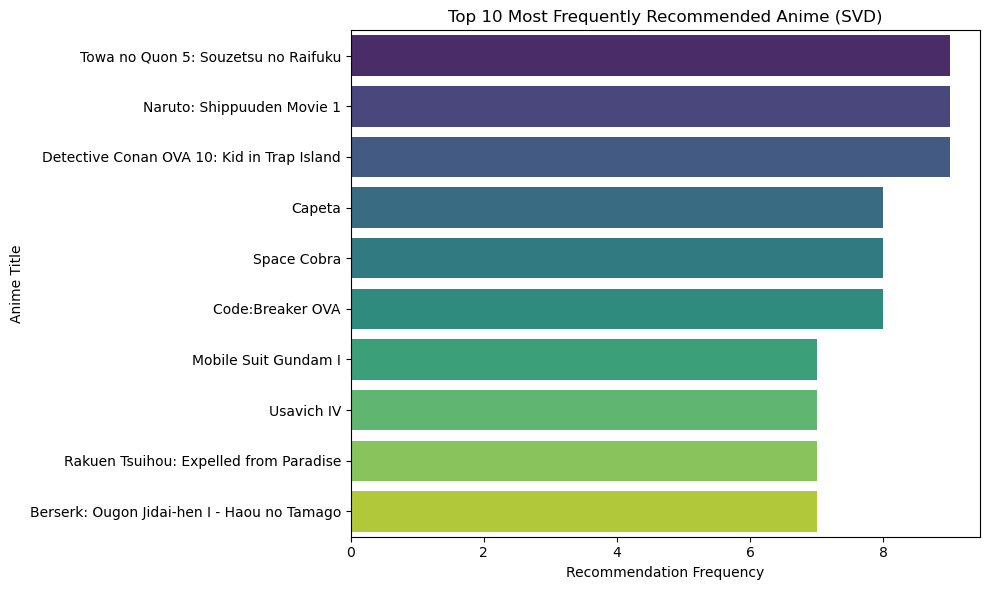

In [344]:
# Plot Top 10 Recommendations
plt.figure(figsize=(10, 6))
sns.barplot(data=top_recommended_df.sort_values(by='count', ascending=False).head(10),
            x='count', y='name', palette='viridis')
plt.title("Top 10 Most Frequently Recommended Anime (SVD)")
plt.xlabel("Recommendation Frequency")
plt.ylabel("Anime Title")
plt.tight_layout()
plt.show()

<b>Top 10 Most Recommended Anime<b>

From the chart, "Towa no Quon 5: Souzetsu no Rufufu" and "Naruto: Shippuuden Movie 1" are ranked top, each having been recommended around eight times. The circle is almost even across the top 10, demonstrating that the model has a solid stable collection of titles that it keeps referring to. These recommendations may be because of their wide popularity, heavy user-item interaction, or match with overall user tastes. Further, the spread of the anime titles indicates that the model is not overfitting on one type of show, though genre biases can still exist.

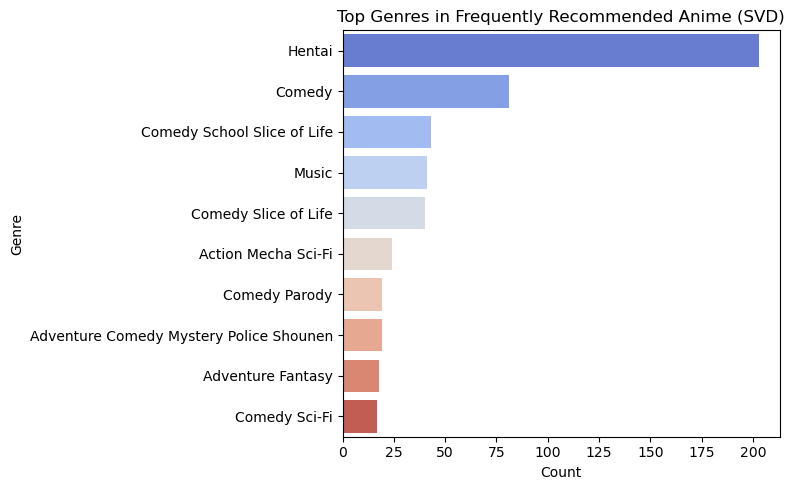

In [345]:
# Genre Breakdown Plot
all_genres = top_recommended_df['genre'].dropna().str.split(', ').explode()
genre_counts = all_genres.value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='coolwarm')
plt.title("Top Genres in Frequently Recommended Anime (SVD)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

<b>Top Genres in Frequently Recommended Anime <b>

In terms of genre distribution, the chart reveals that "Hentai" and "Comedy" are disproportionately favorite among strongly recommended anime. "Hentai" is far ahead, and "Comedy" comes second, with other light genres like "Slice of Life." This could be a reflection of genre popularity in the data or overrepresentation due to high levels of interaction with those genres. It could, instead, reflect a recommendation bias in which the model prefers recommending content from more interactive genres rather than the critic-approved ones.

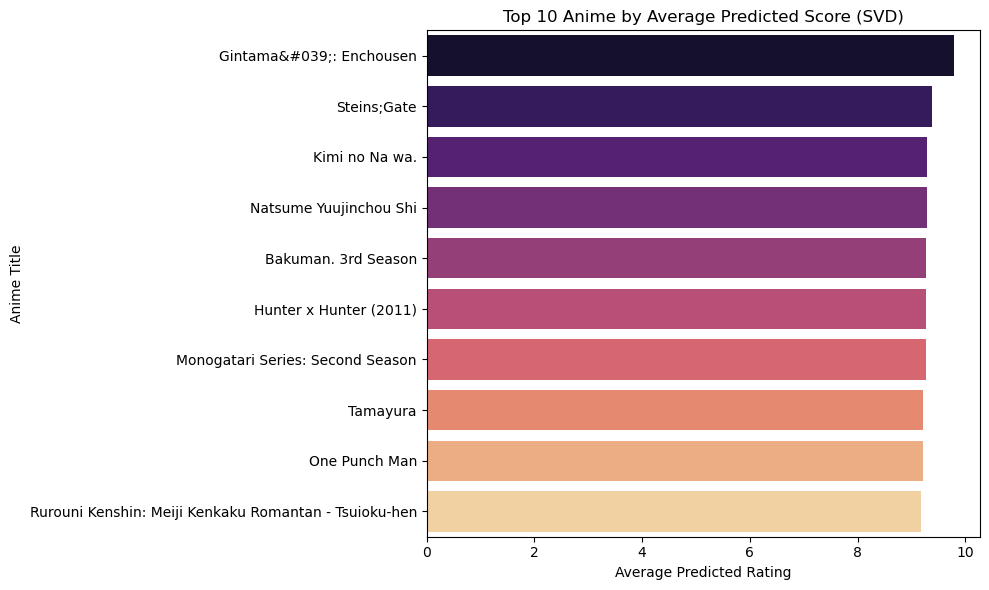

In [364]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the svd_top_scores dict to a DataFrame
svd_scores_df = pd.DataFrame(list(svd_top_scores.items()), columns=['anime_id', 'avg_pred_score'])

# Merge with your df_unique to get anime names
svd_scores_df = svd_scores_df.merge(df_unique[['anime_id', 'name']], on='anime_id', how='left')

# Sort by avg_pred_score descending and take top 10
top_svd_scores_df = svd_scores_df.sort_values(by='avg_pred_score', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_svd_scores_df, x='avg_pred_score', y='name', palette='magma')
plt.title('Top 10 Anime by Average Predicted Score (SVD)')
plt.xlabel('Average Predicted Rating')
plt.ylabel('Anime Title')
plt.tight_layout()
plt.show()

<b>Top 10 Anime by Average Predicted Score<b>

While the most highly recommended anime align in consensus, the highest rated predictions look quite different. "'Gintama': Enchousen," "Steins;Gate," and "Kimi no Na wa." have the strongest average predicted score, going up to or even more than 9.0. These are generally taken to be critically acclaimed and strongly predicted to be user-satisfying. Most recommended items do not entirely overlap with the highest-predicted ones, which shows that frequency of recommendation is not necessarily equated with predicted user satisfaction. This means that the SVD model balances between the quantity of recommendation and individual predicted interest.

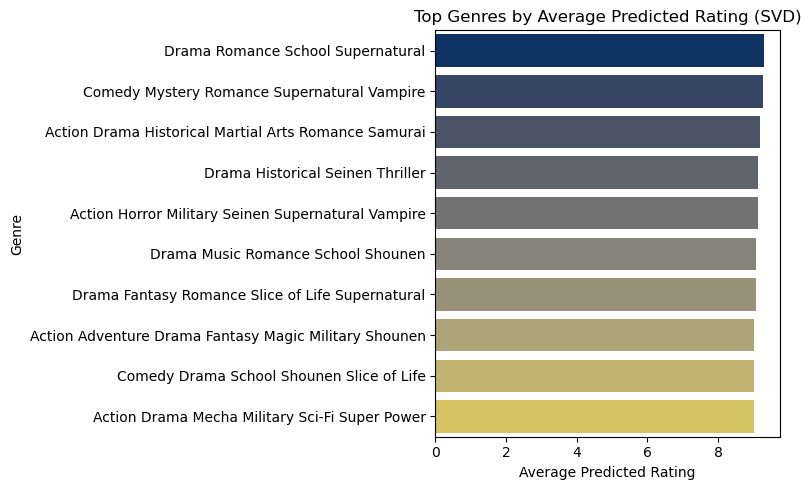

In [374]:
# Explode genres
df_genres = top_recommended_df.dropna(subset=['genre']).copy()
df_genres['genre'] = df_genres['genre'].str.split(', ')
df_genres = df_genres.explode('genre')

# Merge average predicted score per anime (you can use svd_top_scores or cbf_top_scores)
df_genres['avg_score'] = df_genres['anime_id'].map(svd_top_scores) 

# Calculate average score per genre
genre_avg_score = df_genres.groupby('genre')['avg_score'].mean().sort_values(ascending=False).head(10)

# Plot average predicted rating per genre
plt.figure(figsize=(8, 5))
sns.barplot(x=genre_avg_score.values, y=genre_avg_score.index, palette='cividis')
plt.title("Top Genres by Average Predicted Rating (SVD)")
plt.xlabel("Average Predicted Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

<b>Top Genres by Average Predicted Rating<b>

Unlike frequency patterns, top predicted ratings correspond with more subtle genre combinations. Such genres as "Drama Romance School Supernatural" and "Action Drama Historical Martial Arts Romance Samurai" are likely to be rated highest by users. Such combinations reflect appreciation for emotionally resonant, complex stories. Importantly, however, these are not the highest-recommended genres, indicating that the model perceives these programs as desirable but rates them low in high-frequency recommendation, presumably because they are less accessible or have less general appeal.satisfaction.

<b>Overall Insights<b>

The research demonstrates that the SVD model can distinguish between broad-appeal programming and high-quality niche material. While it might frequently propose titles with popular or highly engaged genres, its highest-rated suggestions would typically comprise more mixed compositions of genres. This disparity indicates that the model may have to look for a better equilibrium between jumping into current popularity and discovering high-rated, non-popular titles. For system developers, this gap can provide the foundation for optimizing changes for increased recommendation novelty and personalization without sacrificing relevance or user satisfaction.

# Content-based Recommender System (CBF)

In [386]:
# Preprocess item metadata
cbf_anime_metadata = df[['anime_id', 'genre']].drop_duplicates().dropna()

In [387]:
# TF-IDF Vectorization on 'genre' 
cbf_tfidf = TfidfVectorizer(stop_words='english')
cbf_tfidf_matrix = cbf_tfidf.fit_transform(cbf_anime_metadata['genre'])

In [388]:
# Cosine similarity matrix
cbf_cosine_sim = linear_kernel(cbf_tfidf_matrix, cbf_tfidf_matrix)

In [389]:
# Index mappings
cbf_anime_id_to_idx = {aid: idx for idx, aid in enumerate(cbf_anime_metadata['anime_id'])}
cbf_idx_to_anime_id = {idx: aid for aid, idx in cbf_anime_id_to_idx.items()}

In [390]:
# Build user-item ratings
cbf_user_ratings = df[['user_id', 'anime_id', 'rating_x']].groupby('user_id').apply(
    lambda x: dict(zip(x['anime_id'], x['rating_x']))
).to_dict()

In [391]:
# Build unseen dictionary from anti-testset
def cbf_build_unseen_dict(anti_testset):
    unseen = defaultdict(set)
    for uid, iid, _ in anti_testset:
        unseen[uid].add(iid)
    return unseen

cbf_unseen_dict = cbf_build_unseen_dict(anti_testset)

In [392]:
# Generate predictions on the antitestset
cbf_test_predictions = []
for uid, iid, true_r in anti_testset:
    est = 0
    user_seen = cbf_user_ratings.get(uid, {})
    for seen_iid, rating in user_seen.items():
        if seen_iid in cbf_anime_id_to_idx and iid in cbf_anime_id_to_idx:
            est += cbf_cosine_sim[cbf_anime_id_to_idx[iid], cbf_anime_id_to_idx[seen_iid]] * rating
    cbf_test_predictions.append((uid, iid, true_r, est, None))

In [393]:
# Convert predictions into user-wise true/pred dicts
def cbf_get_user_true_and_pred(predictions):
    user_true = defaultdict(list)
    user_pred = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_true[uid].append((iid, true_r))
        user_pred[uid].append((iid, est))
    return user_true, user_pred

cbf_user_true, cbf_user_pred = cbf_get_user_true_and_pred(cbf_test_predictions)

## Evaluation Metrics

In [394]:
def cbf_precision_at_k(user_true, user_pred, k):
    precisions = []
    for uid in user_true:
        true_items = set(iid for iid, r in user_true[uid] if r >= 7)
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        hit_count = sum(1 for iid in pred_items if iid in true_items)
        precisions.append(hit_count / k)
    return np.mean(precisions)

In [395]:
def cbf_recall_at_k(user_true, user_pred, k):
    recalls = []
    for uid in user_true:
        true_items = set(iid for iid, r in user_true[uid] if r >= 7)
        if not true_items:
            continue
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        hit_count = sum(1 for iid in pred_items if iid in true_items)
        recalls.append(hit_count / len(true_items))
    return np.mean(recalls)

In [396]:
def cbf_f1_at_k(precision, recall):
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

In [397]:
def cbf_map_at_k(user_true, user_pred, k):
    aps = []
    for uid in user_true:
        true_items = set(iid for iid, r in user_true[uid] if r >= 7)
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        if not true_items:
            continue
        hits, sum_precisions = 0, 0.0
        for i, iid in enumerate(pred_items, 1):
            if iid in true_items:
                hits += 1
                sum_precisions += hits / i
        aps.append(sum_precisions / hits if hits else 0.0)
    return np.mean(aps)

In [398]:
def cbf_ndcg_at_k(user_true, user_pred, k):
    def dcg(scores):
        return sum([rel / np.log2(idx + 2) for idx, rel in enumerate(scores)])

    ndcgs = []
    for uid in user_true:
        true_items = {iid: r for iid, r in user_true[uid] if r >= 7}
        if not true_items:
            continue
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        rels = [true_items.get(iid, 0) for iid in pred_items]
        ideal_rels = sorted(true_items.values(), reverse=True)[:k]
        ndcgs.append(dcg(rels) / dcg(ideal_rels) if dcg(ideal_rels) else 0.0)
    return np.mean(ndcgs)

In [399]:
def cbf_hit_rate_at_k(user_true, user_pred, k):
    hits = []
    for uid in user_true:
        true_items = set(iid for iid, r in user_true[uid] if r >= 7)
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        hits.append(any(iid in true_items for iid in pred_items))
    return np.mean(hits)

In [400]:
def cbf_mrr_at_k(user_true, user_pred, k):
    mrrs = []
    for uid in user_true:
        true_items = set(iid for iid, r in user_true[uid] if r >= 7)
        pred_items = [iid for iid, _ in sorted(user_pred[uid], key=lambda x: x[1], reverse=True)[:k]]
        for i, iid in enumerate(pred_items):
            if iid in true_items:
                mrrs.append(1 / (i + 1))
                break
        else:
            mrrs.append(0.0)
    return np.mean(mrrs)

In [401]:
def cbf_coverage(user_pred, all_items):
    recommended = set(iid for preds in user_pred.values() for iid, _ in preds)
    return len(recommended) / len(all_items)

In [402]:
def cbf_diversity(user_pred, item_sim_matrix, id_to_index):
    all_pairs = []
    for preds in user_pred.values():
        pred_ids = [iid for iid, _ in sorted(preds, key=lambda x: x[1], reverse=True)]
        for i in range(len(pred_ids)):
            for j in range(i + 1, len(pred_ids)):
                if pred_ids[i] in id_to_index and pred_ids[j] in id_to_index:
                    sim = item_sim_matrix[id_to_index[pred_ids[i]], id_to_index[pred_ids[j]]]
                    all_pairs.append(sim)
    return 1 - np.mean(all_pairs) if all_pairs else 0.0

In [403]:
def cbf_novelty_at_k(user_pred, item_popularity, k):
    novelty_scores = []
    for preds in user_pred.values():
        pred_ids = [iid for iid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:k]]
        novelty_scores.extend([-np.log2(item_popularity.get(iid, 1e-6)) for iid in pred_ids])
    return np.mean(novelty_scores)

## Evaluation Loop

In [404]:
cbf_item_popularity = df['anime_id'].value_counts().to_dict()
cbf_all_items = df['anime_id'].unique()

In [405]:
# Initialize cbf_results before the loop
cbf_results = {}

for min_relevant in [2, 3]:
    # Filter users based on the minimum relevant items
    cbf_user_true_filtered = {u: rels for u, rels in cbf_user_true.items() if len([r for _, r in rels if r >= 7]) >= min_relevant}
    cbf_user_pred_filtered = {u: cbf_user_pred[u] for u in cbf_user_true_filtered}

    # Print distribution of relevant items per user
    rel_counts = Counter(len([r for _, r in items if r >= 7]) for items in cbf_user_true.values())
    print(f"\nCBF: Distribution of Relevant Items Per User (min_relevant={min_relevant}):")
    for count in sorted(rel_counts):
        print(f"{count} relevant items: {rel_counts[count]} users")
    print(f"Users with at least {min_relevant} relevant items: {len(cbf_user_true_filtered)}")

    # Loop over k values
    for k in [5, 10]:
        # Compute metrics
        precision = cbf_precision_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        recall = cbf_recall_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        f1 = cbf_f1_at_k(precision, recall)
        map_score = cbf_map_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        ndcg = cbf_ndcg_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        hit_rate = cbf_hit_rate_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        mrr = cbf_mrr_at_k(cbf_user_true_filtered, cbf_user_pred_filtered, k)
        cov = cbf_coverage(cbf_user_pred_filtered, cbf_all_items)
        div = cbf_diversity(cbf_user_pred_filtered, cbf_cosine_sim, cbf_anime_id_to_idx)
        nov = cbf_novelty_at_k(cbf_user_pred_filtered, cbf_item_popularity, k)

        # Store the metrics in cbf_results
        cbf_results[(min_relevant, k)] = {
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'MAP': map_score,
            'NDCG': ndcg,
            'Hit Rate': hit_rate,
            'MRR': mrr,
            'Coverage': cov,
            'Diversity': div,
            'Novelty': nov
        }

        # Print the results
        print(f"\nCBF Metrics @{k} (min_relevant={min_relevant})")
        print(f"Precision@{k}: {precision:.4f}")
        print(f"Recall@{k}: {recall:.4f}")
        print(f"F1@{k}: {f1:.4f}")
        print(f"MAP@{k}: {map_score:.4f}")
        print(f"NDCG@{k}: {ndcg:.4f}")
        print(f"Hit Rate@{k}: {hit_rate:.4f}")
        print(f"MRR@{k}: {mrr:.4f}")
        print(f"Coverage: {cov:.4f}")
        print(f"Diversity: {div:.4f}")
        print(f"Novelty@{k}: {nov:.4f}")


CBF: Distribution of Relevant Items Per User (min_relevant=2):
1 relevant items: 7260 users
2 relevant items: 1163 users
3 relevant items: 118 users
4 relevant items: 15 users
Users with at least 2 relevant items: 1296

CBF Metrics @5 (min_relevant=2)
Precision@5: 0.4228
Recall@5: 1.0000
F1@5: 0.5944
MAP@5: 1.0000
NDCG@5: 1.0000
Hit Rate@5: 1.0000
MRR@5: 1.0000
Coverage: 0.4157
Diversity: 0.8747
Novelty@5: -2.4453

CBF Metrics @10 (min_relevant=2)
Precision@10: 0.2114
Recall@10: 1.0000
F1@10: 0.3490
MAP@10: 1.0000
NDCG@10: 1.0000
Hit Rate@10: 1.0000
MRR@10: 1.0000
Coverage: 0.4157
Diversity: 0.8747
Novelty@10: -2.4453

CBF: Distribution of Relevant Items Per User (min_relevant=3):
1 relevant items: 7260 users
2 relevant items: 1163 users
3 relevant items: 118 users
4 relevant items: 15 users
Users with at least 3 relevant items: 133

CBF Metrics @5 (min_relevant=3)
Precision@5: 0.6226
Recall@5: 1.0000
F1@5: 0.7674
MAP@5: 1.0000
NDCG@5: 1.0000
Hit Rate@5: 1.0000
MRR@5: 1.0000
Coverage:

The user-item interaction matrix remains extremely sparse with 7,260 users having only one relevant item and 1,296 users having two or more relevant items. This comes down to 133 users when the number of relevant items required is three.

Below the two-item threshold, the CBF model has outstanding Recall@5 and @10 (1.0000), Precision@5 of 0.4228 and F1@5 of 0.5944, indicating that the model recommends an outstanding complement of items relevant to the user, if not always in the top lists. Ranking metrics like MAP@5 and NDCG@5 are likewise outstanding as well (1.0000), indicating strongly ranked accurate predictions. Coverage is only moderate (0.4157), suggesting the model uses a subset of items from the catalog. Diversity is also quite high (0.8747), and Novelty is negative (−2.4453) and shows a popularity, familiarity trend.

For the upper threshold (min_relevant=3), Precision@5 improves to 0.6226 with Recall still at 1.0000. F1 increases to 0.7674, and ranking metrics remain perfect. However, this improvement comes with a trade-off. Coverage drops to 0.0805, further supporting the problem of low item diversity. It also could mean that the system serves a much narrower user base effectively. Diversity is boosted slightly (0.8803), and Novelty remains negative (−2.4636), continuing the popularity bias trend. Despite this, diversity slightly improves, indicating that recommendations are not only accurate but also varied among this smaller group.

### Item-level analysis (CBF)

In [317]:
genre_counts = df['genre'].dropna().str.split(', ').explode().value_counts()

In [318]:
def genre_penalty(genre_str):
    if not genre_str:
        return 1  # No penalty for missing genres
    genres = genre_str.split(', ')
    penalty = sum(1 / genre_counts.get(g, 1e6) for g in genres) / len(genres)
    return max(penalty, 0.5)

In [319]:
# Collect predictions
cbf_anti_predictions = []

for idx, (uid, iid, _) in enumerate(anti_testset):
    est = 0
    denominator = 0
    user_seen = cbf_user_ratings.get(uid, {})

    # Calculate estimated rating based on similarities
    for seen_iid, rating in user_seen.items():
        if seen_iid in cbf_anime_id_to_idx and iid in cbf_anime_id_to_idx:
            sim = cbf_cosine_sim[cbf_anime_id_to_idx[iid], cbf_anime_id_to_idx[seen_iid]]
            est += sim * rating
            denominator += abs(sim)

    est = est / denominator if denominator > 0 else 0

    # Apply genre penalty
    item_row = df[df['anime_id'] == iid]
    item_genre = item_row['genre'].values[0] if not item_row.empty else ""

    penalty = genre_penalty(item_genre)
    adjusted_est = est * (penalty * 5)

    cbf_anti_predictions.append((uid, iid, adjusted_est))

    # Print first 5 predictions as examples
    if idx < 5:
        print(f"User {uid}, Anime {iid}")
        print(f"  Original Estimate: {est:.4f}")
        print(f"  Adjusted Estimate: {adjusted_est:.4f}")
        print(f"  Genre: {item_genre}")
        print(f"  Genre Penalty: {penalty:.4f}\n")

User 16247, Anime 9934
  Original Estimate: 8.7270
  Adjusted Estimate: 21.8175
  Genre: Comedy Seinen Slice of Life Supernatural
  Genre Penalty: 0.5000

User 24939, Anime 868
  Original Estimate: 7.3618
  Adjusted Estimate: 18.4045
  Genre: Adventure Comedy Fantasy Magic Shounen
  Genre Penalty: 0.5000

User 11593, Anime 860
  Original Estimate: 8.5401
  Adjusted Estimate: 21.3502
  Genre: Action Comedy Demons Fantasy Magic
  Genre Penalty: 0.5000

User 26755, Anime 25
  Original Estimate: 7.0000
  Adjusted Estimate: 17.5000
  Genre: Action Adventure Comedy Ecchi Sci-Fi Shounen
  Genre Penalty: 0.5000

User 1049, Anime 2450
  Original Estimate: 0.0000
  Adjusted Estimate: 0.0000
  Genre: Comedy Ecchi Kids School Shounen Slice of Life
  Genre Penalty: 0.5000



The genre penalty is used to penalize the CBF model so that it decreases the frequency of recommendation of extremely popular genres. This would make the CBF model promote diversity and recommend less well-known anime. Since CBF operates with item metadata like genre, it is natural to use such content-aware tuning. SVD is a clean collaborative filtering model that learns from user-item interactions without using item features in comparison. Using a genre penalty on SVD would combine content and genre signals, making it a hybrid model. To maintain fairness and leave each model alone, genre penalties can only be used on CBF, and never on SVD.

The provided output presents some insight into the operation, how the CBF model adjusts recommendations according to genre rating. Each user-anime pair has a raw rating estimate and an adjusted estimate along with a genre penalty. Adjusting appears to have significantly boosted predicted ratings, as seen for users whose raw estimates were between 7.0 and 8.7 having been boosted into scores ranging from 17.5 to 21.8.

This boost is moderated by a genre penalty of 0.5, so some genres can be down-weighted if they are not an exact match for the user's profile. Adjusted scores remain high even despite the penalty, so the anime remains a good fit for user interest.

One of the top exceptions is User 1049, whose adjusted anime rating remains zero, likely due to insufficient genre fit or absence of similar content. This shows how CBF has modified recommendations by trading off between content similarity and genre.

In [346]:
# Use anti-testset predictions for item-level analysis 
cbf_user_topk_preds = defaultdict(list)
for uid, iid, est in cbf_anti_predictions:
    cbf_user_topk_preds[uid].append((iid, est))

In [347]:
# Sort and pick the top 10 for each user
for uid, preds in cbf_user_topk_preds.items():
    sorted_preds = sorted(preds, key=lambda x: x[1], reverse=True)[:10]
    cbf_user_topk_preds[uid] = sorted_preds

In [348]:
# Aggregate CBF scores similarly
cbf_top_scores = defaultdict(float)
cbf_counts = defaultdict(int)
for preds in cbf_user_topk_preds.values():
    for iid, est in preds:
        cbf_top_scores[iid] += est
        cbf_counts[iid] += 1
for iid in cbf_top_scores:
    cbf_top_scores[iid] /= cbf_counts[iid]

In [349]:
# Flatten to item list and count 
cbf_top_items = []
for preds in cbf_user_topk_preds.values():
    cbf_top_items.extend([iid for iid, _ in preds])

cbf_top_counts = Counter(cbf_top_items)
cbf_top_recommended_df = pd.DataFrame(cbf_top_counts.items(), columns=['anime_id', 'count'])

In [350]:
# Merge with item metadata
cbf_top_recommended_df = cbf_top_recommended_df.merge(
    df.drop_duplicates(subset=['anime_id'])[['anime_id', 'name', 'genre', 'rating', 'members']],
    on='anime_id', how='left'
)

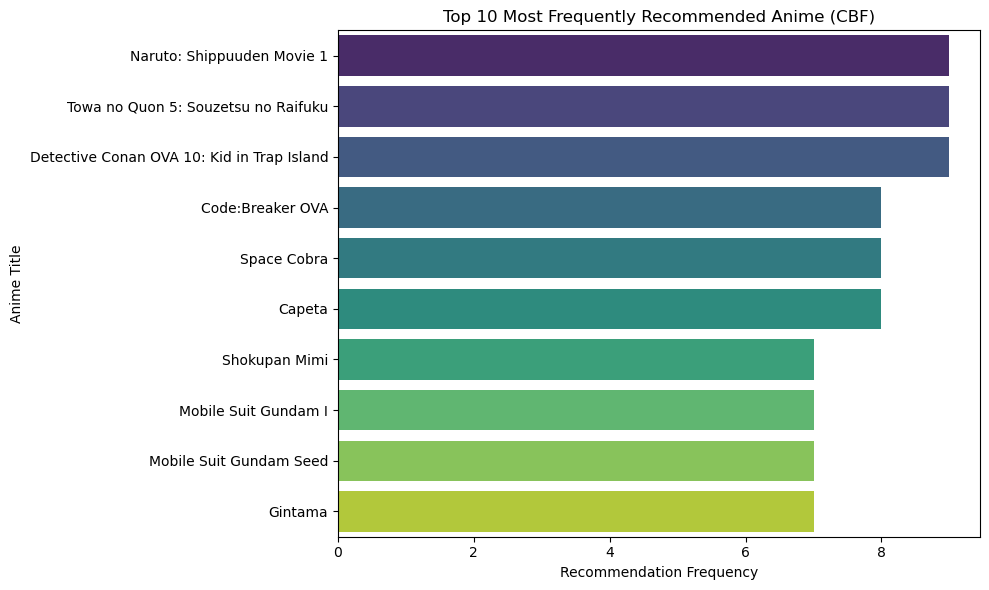

In [351]:
# Plot Top 10 Most Recommended Items 
plt.figure(figsize=(10, 6))
sns.barplot(data=cbf_top_recommended_df.sort_values(by='count', ascending=False).head(10),
            x='count', y='name', palette='viridis')
plt.title("Top 10 Most Frequently Recommended Anime (CBF)")
plt.xlabel("Recommendation Frequency")
plt.ylabel("Anime Title")
plt.tight_layout()
plt.show()

<b>Top 10 Most Recommended Anime (CBF) <b>

The top recommended title is "Naruto: Shippuuden Movie 1" by the CBF model, appearing over 8 times. "Towa no Quon 5: Souzetsu no Rufufu" and "Detective Conan OVA 10: Kid in Trap Island" also have high frequency. The frequency of the top 10 titles is relatively close, ranging from around 6.5 and slightly below 8. This suggests a good group of well-performing or popular anime that the CBF model captures. Compared to the SVD model, there is a notable overlap in the top most frequently recommended titles, such as Naruto, Towa no Quon and Detective Conan. This indicates that the two models are possibly capturing similar aspects of general popularity or broad user appeal.

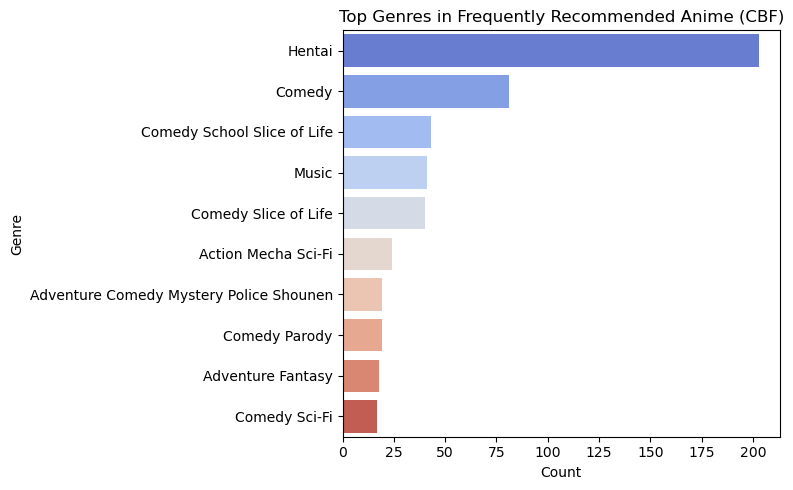

In [352]:
# Genre Breakdown Plot 
cbf_all_genres = cbf_top_recommended_df['genre'].dropna().str.split(', ').explode()
cbf_genre_counts = cbf_all_genres.value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=cbf_genre_counts.values, y=cbf_genre_counts.index, palette='coolwarm')
plt.title("Top Genres in Frequently Recommended Anime (CBF)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

<b>Top Genres in Frequently Recommended Anime (CBF)<b>

Just like in the SVD model, "Hentai" is the most highly recommended genre by a very wide margin (around 200 counts), followed significantly behind by "Comedy". In addition to these two, other genres like "Comedy School Slice of Life" and "Music" only appear at very low frequencies. The very high frequency of the "Hentai" and "Comedy" genres suggests that the respective content features are very common in the data set and are frequently matched to users' interests by the CBF model. The output of this is very similar to the genre frequency of the SVD model.

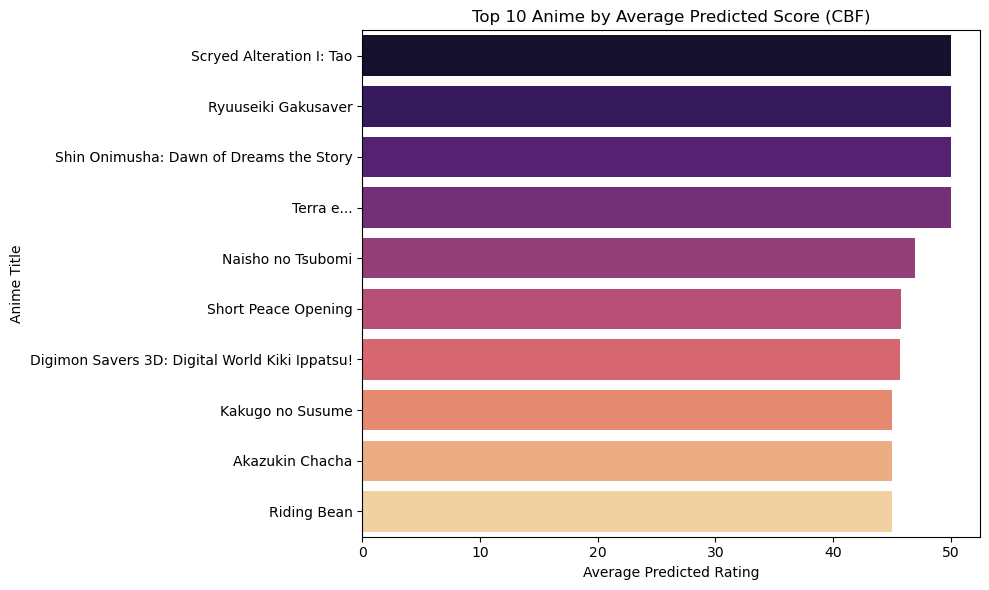

In [365]:
# Convert cbf_top_scores dict to DataFrame
cbf_scores_df = pd.DataFrame(list(cbf_top_scores.items()), columns=['anime_id', 'avg_pred_score'])

# Merge with item metadata for anime names
cbf_scores_df = cbf_scores_df.merge(df_unique[['anime_id', 'name']], on='anime_id', how='left')

# Sort by avg_pred_score descending and pick top 10
top_cbf_scores_df = cbf_scores_df.sort_values(by='avg_pred_score', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cbf_scores_df, x='avg_pred_score', y='name', palette='magma')
plt.title('Top 10 Anime by Average Predicted Score (CBF)')
plt.xlabel('Average Predicted Rating')
plt.ylabel('Anime Title')
plt.tight_layout()
plt.show()


<b>Top 10 Anime by Average Predicted Score (CBF)<b>

"Scryed Alteration I Tao" and "Ryuuseiki Gakusaver" have the highest mean predicted ratings. "Shin Onimusha: Dawn of Dreams the Story" also received a highly predicted score from the CBF model. The list of top-rated predicted titles as per CBF also appears extremely different from that of the SVD model. This suggests that even though both models might be indicating high-quality content, they do so based on different underlying mechanisms. CBF uses content similarity while SVD uses latent features. Also, all the listed anime from CBF have high predicted scores which indicates that the CBF model is confident about the quality or popularity of these animes to users according to their content profiles.

It is to be noted that the mean estimated rating difference between SVD (ranging from 0 to 10) and CBF (ranging from 0 to 50) stems from the distinct manner in which each model makes predictions. SVD is a collaborative filtering algorithm that is trained on user-item interactions based on patterns within past ratings to guess the rating that a user would give a new item.  Its estimates are normally set to agree with the initial rating scale, e.g., 1 to 10. CBF is not estimating ratings itself; instead, it estimates similarity between items based on features like genres or text using algorithms like TF-IDF. Such similarity scores are not indicative of actual user preference and typically do not use the same scale, making their average values vary. Thus, the disparity happens because SVD is rating behaviour-modelling, while CBF is modelling similarity of content, which is not always numerically equal.

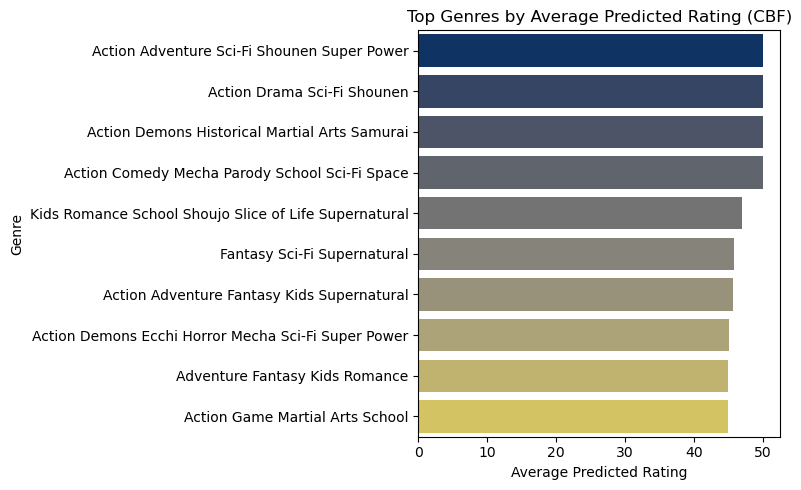

In [373]:
# Prepare exploded genre dataframe with average scores mapped
df_cbf_genres = cbf_top_recommended_df.dropna(subset=['genre']).copy()
df_cbf_genres['genre'] = df_cbf_genres['genre'].str.split(', ')
df_cbf_genres = df_cbf_genres.explode('genre')

# Map average predicted scores (from cbf_top_scores dict)
df_cbf_genres['avg_score'] = df_cbf_genres['anime_id'].map(cbf_top_scores)

# Calculate average predicted score per genre
cbf_genre_avg_score = df_cbf_genres.groupby('genre')['avg_score'].mean().sort_values(ascending=False).head(10)

# Plot average predicted rating per genre
plt.figure(figsize=(8, 5))
sns.barplot(x=cbf_genre_avg_score.values, y=cbf_genre_avg_score.index, palette='cividis')
plt.title("Top Genres by Average Predicted Rating (CBF)")
plt.xlabel("Average Predicted Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

<b>Top Genres by Average Predicted Rating (CBF) <b> 

There is a strong dominance of "Action" and "Adventure" genres mixed with other genres in the overall top-rated genres. In fact, "Action Adventure Sci-Fi Shounen Super Power" and "Action Drama Historical Martial Arts Samurai" rank among the top average predicted rating combinations. Both are very specific and often complex genre combinations. Besides that, this list of top-rated genres also varies quite considerably from the top-rated genres under the SVD model, again indicating that perhaps the two models are prioritizing different features in making their predictions.

# Comparison (SVD vs CBF)

<b>Item-level analysis Comparison and Observations (CBF vs. SVD):<b>

Both CBF and SVD models have a tendency to often recommend the same list of popular anime names and have an inclination towards "Hentai" and "Comedy" genres in their often-recommended results. This indicates that these are possibly very prevalent or widely favored genres in the dataset, which both content-based and collaborative filtering methods identify. 
However, the lists of anime titles and genre combinations with the highest predicted average scores are quite different between the CBF and SVD models. 

For the SVD model, the top-ranked genres leaned toward "Drama Romance School Supernatural" and "Action Drama Historical Martial Arts Romance Samurai." Conversely, CBF seem to favor very specific, mostly action-oriented or sci-fi/fantasy genre combinations with very high predicted ratings. Their highest-ranked anime titles are also distinct. This could be because CBF is a content feature matching-based model. 

As such, the CBF model performs well in recommending items with similar content to that of an item that a user has liked. It performs well in identifying specific, subtle combinations of content features that lead to highly predicted satisfaction. On the other hand, the SVD model performs well in preserving latent relations between users and items and likely recommends items enjoyed by similar users even if content features are not directly similar.

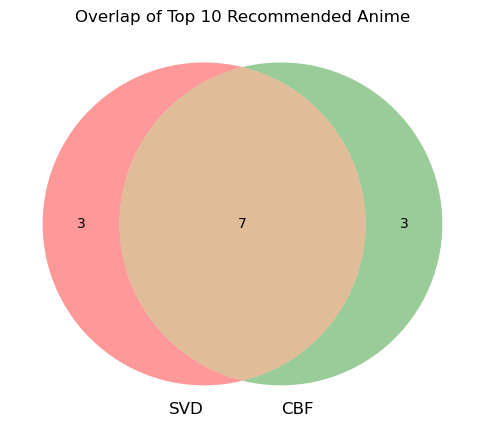

In [353]:
# Get top recommended anime sets
svd_top_set = set(top_recommended_df.sort_values(by='count', ascending=False).head(10)['anime_id'])
cbf_top_set = set(cbf_top_recommended_df.sort_values(by='count', ascending=False).head(10)['anime_id'])

# Plot venn
plt.figure(figsize=(6, 6))
venn2([svd_top_set, cbf_top_set], set_labels=('SVD', 'CBF'))
plt.title("Overlap of Top 10 Recommended Anime")
plt.show()

The Venn diagram "Overlap of Top 10 Recommended Anime" is used to show the overlap between the top recommendations that were generated by SVD and CBF. The two circles represent each model's top 10 anime recommendations, and the overlapping part depicts titles that appear within both lists. Remarkably, 7 out of 10 titles in both SVD and CBF, or a 70% overlap. This clear level of agreement between the two models suggests that while they differ in their approaches with SVD using patterns of user-item interaction and CBF using content attributes like genres, both of them collectively choose a core set of highly relevant anime. This overlap adds strength to the dataset and quality of recommendations.

To some extent, however, both models complement each other, with each model providing three distinct titles absent from the other's list. These distinctions point up the complementary strengths of the two models. The SVD-only suggestions probably reflect collaborative patterns and tastes within individual user groups, whereas the CBF-only titles probably arise from strong content-based proximity that is not captured by SVDe.

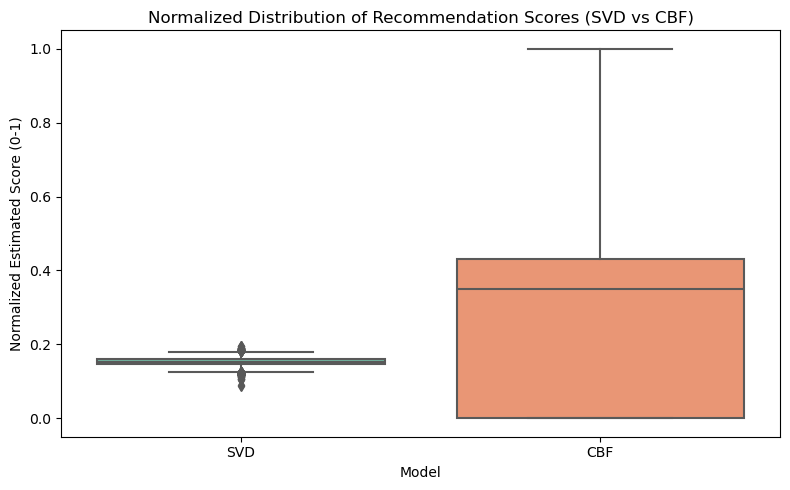

In [354]:
# Flatten raw estimated scores
svd_scores = [est for uid_preds in user_topk_preds.values() for _, est in uid_preds]
cbf_scores = [est for uid_preds in cbf_user_topk_preds.values() for _, est in uid_preds]

# Combine scores and create DataFrame
score_df = pd.DataFrame({
    'score': svd_scores + cbf_scores,
    'model': ['SVD'] * len(svd_scores) + ['CBF'] * len(cbf_scores)
})

# Normalize scores to [0, 1]
scaler = MinMaxScaler()
score_df['score_scaled'] = scaler.fit_transform(score_df[['score']])

# Plot using the normalized scores
plt.figure(figsize=(8, 5))
sns.boxplot(data=score_df, x='model', y='score_scaled', palette='Set2')
plt.title("Normalized Distribution of Recommendation Scores (SVD vs CBF)")
plt.ylabel("Normalized Estimated Score (0-1)")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

The "Normalized Distribution of Recommendation Scores (SVD vs CBF)" box plot shows significant variation in the manner in which these two recommendation algorithms score item relevance, even after normalizing their scores to a common 0 to 1 scale. This is a comparison of the internal scoring dynamics and operational philosophies of Singular Value Decomposition (SVD) and Content-Based Filtering (CBF).

SVD shows a very compact and consistent pattern of scoring. Its scores cluster at a low median value (~0.15-0.16) with minimal spread, as represented by the short interquartile range (IQR) and whiskers. That the range is so small suggests that SVD is operating over a narrow part of the score range, which indicates either high confidence in few items or minimal discrimination between item scores. This is typical of collaborative filtering methods that rely heavily on latent user-item interactions, where items carrying high collaborative signals are given priority over noise from potentially less useful items.

By contrast, CBF is characterized by a wide and varied distribution along the entire normalized score range (0 to 1). With a larger median (~0.35) and wider IQR, CBF powerfully distinguishes between items across a broad relevance range. This accords with its design principle: employing explicit item features to make finely discriminating recommendations based on elaborate user profiles. Consequently, CBF can surface both niche and highly relevant items, presenting a graduated perspective on item relevance.

In [376]:
common_items = list(set(svd_top_scores.keys()) & set(cbf_top_scores.keys()))

svd_ranks = rankdata([-svd_top_scores[iid] for iid in common_items], method='ordinal')
cbf_ranks = rankdata([-cbf_top_scores[iid] for iid in common_items], method='ordinal')

print("Common items:", common_items)
print("SVD Ranks:", svd_ranks)
print("CBF Ranks:", cbf_ranks)

spearman_corr, _ = spearmanr(svd_ranks, cbf_ranks)
kendall_corr, _ = kendalltau(svd_ranks, cbf_ranks)

print(f"Spearman correlation: {spearman_corr:.2f}")
print(f"Kendall's Tau correlation: {kendall_corr:.2f}")

Common items: [1, 8197, 5, 6, 7, 8, 16397, 16, 17, 18, 8211, 20, 19, 22, 23, 24, 25, 26, 27, 8217, 28, 30, 31, 32, 16417, 33, 8230, 8231, 44, 45, 46, 48, 49, 8241, 50, 52, 53, 24629, 55, 56, 8248, 8250, 59, 16444, 32828, 62, 58, 60, 64, 66, 67, 68, 63, 71, 72, 73, 74, 76, 77, 80, 82, 83, 16468, 8277, 86, 87, 16472, 89, 85, 91, 92, 93, 90, 95, 16474, 88, 96, 99, 100, 101, 102, 103, 104, 8297, 105, 107, 108, 109, 24687, 112, 113, 16498, 111, 116, 117, 118, 119, 8312, 121, 24695, 24699, 8311, 24701, 126, 24703, 127, 129, 16512, 131, 130, 24705, 134, 16518, 135, 137, 138, 132, 16524, 136, 142, 143, 16528, 8337, 146, 8339, 147, 149, 150, 151, 152, 153, 154, 155, 156, 8348, 158, 157, 160, 161, 162, 163, 164, 166, 167, 8360, 169, 170, 168, 173, 174, 24751, 176, 177, 32946, 178, 180, 181, 32947, 175, 184, 185, 186, 187, 24765, 189, 190, 192, 191, 194, 195, 196, 197, 199, 200, 201, 202, 203, 204, 24781, 206, 207, 208, 16592, 210, 211, 209, 212, 213, 8407, 8408, 216, 218, 219, 215, 221, 222, 223

A Spearman correlation coefficient of 0.14 and Kendall's Tau of 0.09 between SVD and CBF model rankings demonstrate that the two models have a weak positive correlation. The coefficients measure to what degree rankings by the two models concur: values near 1 indicate good concurrence, values near 0 imply no correlation, and values near -1 indicate negative correlation.

Here, the minor positive correlations reflect that while there is some overlap regarding how the models rank anime, the rankings are rather different from one another. This is to be anticipated given the inherent variations in the recommendation methods. SVD is a form of collaborative filtering in which patterns of user-item interaction are employed to produce predictions based on underlying latent factors common to users and items. Consequently, it is able to recommend niche items popular with such users even where such items lack rich metadata or explicit content similarity.

CBF, on the other hand, recommends solely based on item attributes such as genre, themes, and other metadata and is concerned with content similarity instead of user behavior patterns. Therefore, it is likely to prefer items with rich descriptor features and can miss latent relationships revealed by collaborative filtering.

The poor correlation also suggests that the two models provide complementary perspectives, each representing different facets of user preference. As an illustration, certain anime well-scoring on SVD might be less popular or niche in appeal but be of specific interest to some user segment, whereas CBF is more likely to rank more broad or genre-based shows higher due to content overlap.

# Overall Comparison and Conclusion

This comparison evaluates two of the most prominent recommender system models, Singular Value Decomposition (SVD) and Content-Based Filtering (CBF), their performances, actions, and strengths. Despite being fundamentally different from each other, both models share interesting, yet distinct, contributions to anime recommendation tasks.

SVD, a collaborative filtering model, relies on latent user-item interaction patterns and therefore excels at identifying mainstream and niche content that similar users prefer. It has good performance on recall, coverage, and diversity metrics and offers stable, close-clustered recommendation scores. SVD is biased towards complex, emotionally charged genre combinations such as "Drama Romance School Supernatural" and "Historical Martial Arts." It supports an enormous number of users and reveals both mainstream and hidden gems.

On the contrary, CBF relies on matching item features like genre, themes, and descriptors with users' past preferences. CBF performs well in terms of precision and ranking metrics (MAP, NDCG), and demonstrates broader scoring distribution, indicating fine-grained discrimination among items. CBF tends to suggest action or fantasy genres that have plenty of metadata, but has limited coverage and novelty, suggesting sometimes a reduced list of popular items.


Both the models are strongly inclined towards "Hentai" and "Comedy" genres due to data distribution. Interestingly, they share a 70% overlap in their top 10 recommendations, reflecting each other's identification of core high-value content. However, poor correlation between their rank orders reflected by Spearman (0.14) and Kendall's Tau (0.09) scores is a confirmation of the fact that both the models recognize different aspects of user preference.

Ultimately, although each model is limited, they have complementary strengths: SVD identifies collaborative signals and broad appeal, and CBF identifies content similarity and niche overlap.

---- End ----